# Dataset Exploration
This notebook provides modular tools to analyze and visualize the time series datasets. We can study the full dataset, detect outliers (such as 0 variance series), and visualize specific slices.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data.loaders import load_dataset
from src.utils.visualization import plot_node_time_series, plot_time_series_decomposition
from src.utils.graph_metrics import calculate_graph_metrics

plt.style.use('seaborn-v0_8-whitegrid')

## Configuration & Loading

In [2]:
# --- CONFIGURATION ---
DATASET_NAME = 'PEMS07'  # Try 'PEMS04', 'PEMS08', etc.
DATA_DIR = os.path.join('..', 'data', DATASET_NAME)
FEATURE_IDX = 0  # We usually focus on the first feature

print(f'Loading dataset: {DATASET_NAME}')
dataset_dict = load_dataset(DATA_DIR, load_adj_matrix=True)
data = dataset_dict.get('data')
metadata = dataset_dict.get('metadata')
adj = dataset_dict.get('adj_raw')

print(f'\nData shape: {data.shape} [Time Steps, Nodes, Features]')
L, N, C = data.shape

Loading dataset: PEMS07
--- Dataset Description ---
Dataset Name: PEMS07
Domain: traffic flow
Number of Time Slices: 28224
Number of Nodes (Time Series): 883
Number of features per Node: 3

--- Feature and Structure ---
Features description: traffic flow, time of day, day of week
Time step length: 5 minutes
Prior Graph Structures: Present

--- Model Settings ---
Input Sequence Length: 12
Output Sequence Length: 12
Training Data Ratio: 0.6
Validation Data Ratio: 0.2
Test Data Ratio: 0.2
Individual Channel Normalization: No
Renormalize during Evaluation: Yes
Evaluation Metrics: MAE, RMSE, MAPE
Outlier Handling: 0.0
CWD: c:\Work\Minerva\gnns\matrix-experimentation\notebooks
Attempting to load data with shape [28224, 883, 3]...
Data loaded successfully as a numpy.memmap object.
Data shape: (28224, 883, 3)
Loaded adjacency matrix with shape (883, 883)

Data shape: (28224, 883, 3) [Time Steps, Nodes, Features]


In [3]:
## 1. Outlier & Variance Detection
def detect_zero_variance_nodes(data_array, feature_idx=0, time_slice=None, std_threshold=1e-5):
    """
    Detect nodes that have zero or near-zero variance in a given time slice.
    """
    if time_slice is None:
        slice_data = data_array[:, :, feature_idx]
    else:
        start, end = time_slice
        slice_data = data_array[start:end, :, feature_idx]
        
    std_devs = np.std(slice_data, axis=0)
    zero_var_nodes = np.where(std_devs <= std_threshold)[0]
    
    print(f'Found {len(zero_var_nodes)} nodes with ~0 variance.')
    for idx in zero_var_nodes:
        print(f'Node {idx}: std = {std_devs[idx]:.6f}')
    
    return zero_var_nodes, std_devs

# Example: Check the first 1000 time steps
print('Checking for zero-variance nodes in the first 1000 time steps...')
zero_nodes, stds = detect_zero_variance_nodes(data, feature_idx=FEATURE_IDX, time_slice=(0, 1000))


Checking for zero-variance nodes in the first 1000 time steps...
Found 1 nodes with ~0 variance.
Node 110: std = 0.000000


--- Global Statistics ---
Mean: 308.5236
Std : 188.2457
Min : 0.0000
Max : 1498.0000
0.1% percentile: 0.0000
99.9% percentile: 967.0000


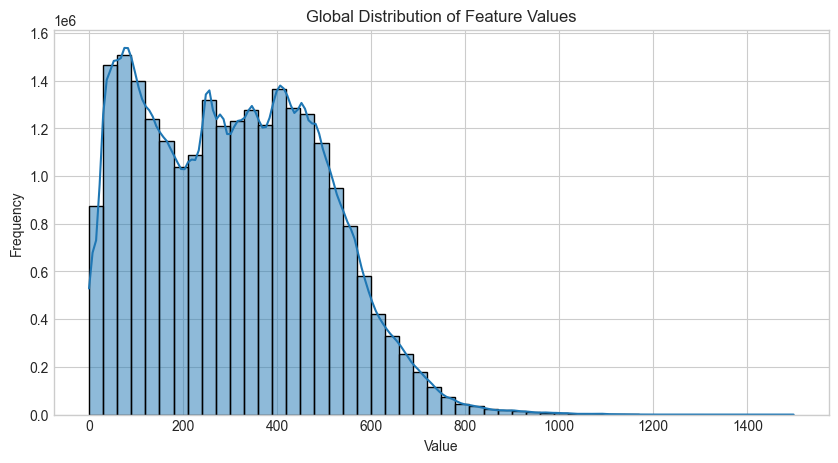

In [4]:
## 2. Basic Dataset Statistics
def analyze_dataset_stats(data_array, feature_idx=0):
    flat_data = data_array[:, :, feature_idx].flatten()
    
    print('--- Global Statistics ---')
    print(f'Mean: {np.mean(flat_data):.4f}')
    print(f'Std : {np.std(flat_data):.4f}')
    print(f'Min : {np.min(flat_data):.4f}')
    print(f'Max : {np.max(flat_data):.4f}')
    print(f'0.1% percentile: {np.percentile(flat_data, 0.1):.4f}')
    print(f'99.9% percentile: {np.percentile(flat_data, 99.9):.4f}')
    
    plt.figure(figsize=(10, 5))
    sns.histplot(flat_data, bins=50, kde=True)
    plt.title('Global Distribution of Feature Values')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

analyze_dataset_stats(data, feature_idx=FEATURE_IDX)

Plotting normal node: 110


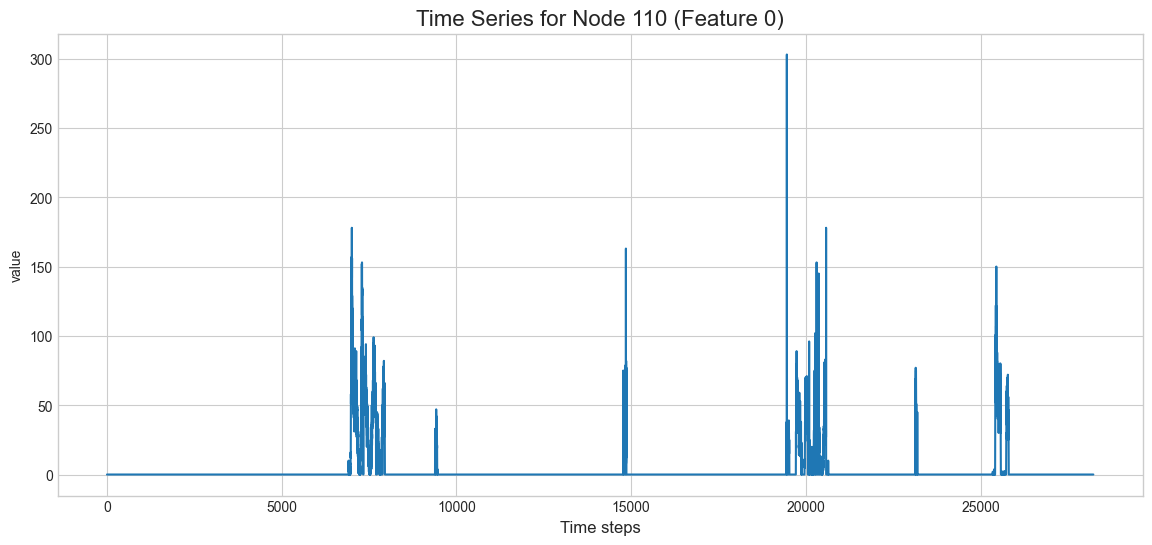

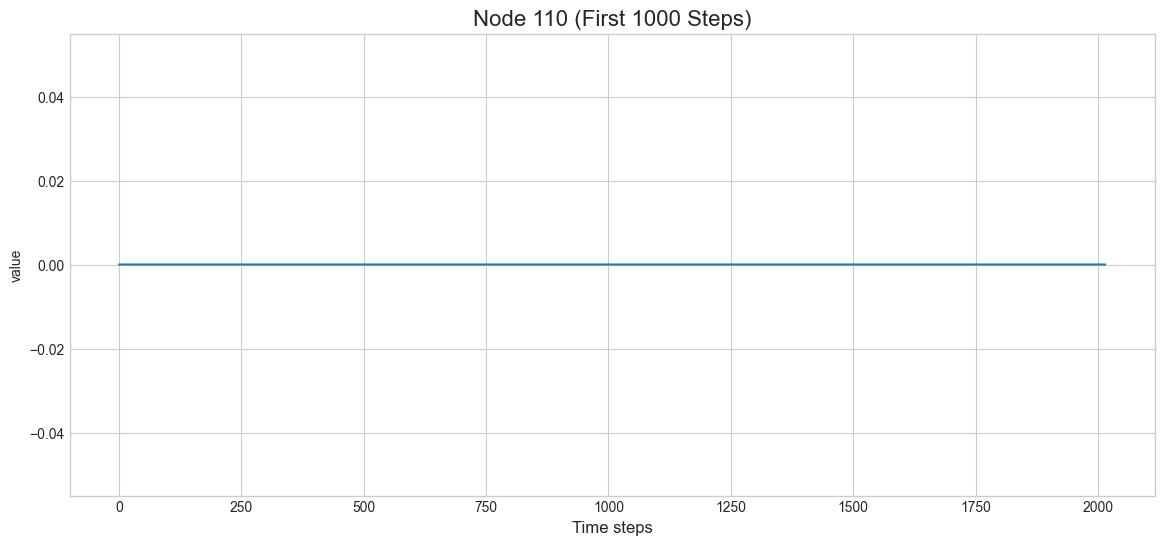

In [23]:
## 3. Node Visualization
# Visualize a normal node and an outlier node if any
node_to_plot = 110
if len(zero_nodes) > 0 and False:
    node_to_plot = zero_nodes[0]
    print(f'Plotting outlier node: {node_to_plot}')
else:
    print(f'Plotting normal node: {node_to_plot}')

plot_node_time_series(data, node_index=node_to_plot, feature_index=FEATURE_IDX, show=True)
plot_node_time_series(data, node_index=node_to_plot, feature_index=FEATURE_IDX, x_0=0, x_1=2016, title=f'Node {node_to_plot} (First 1000 Steps)')


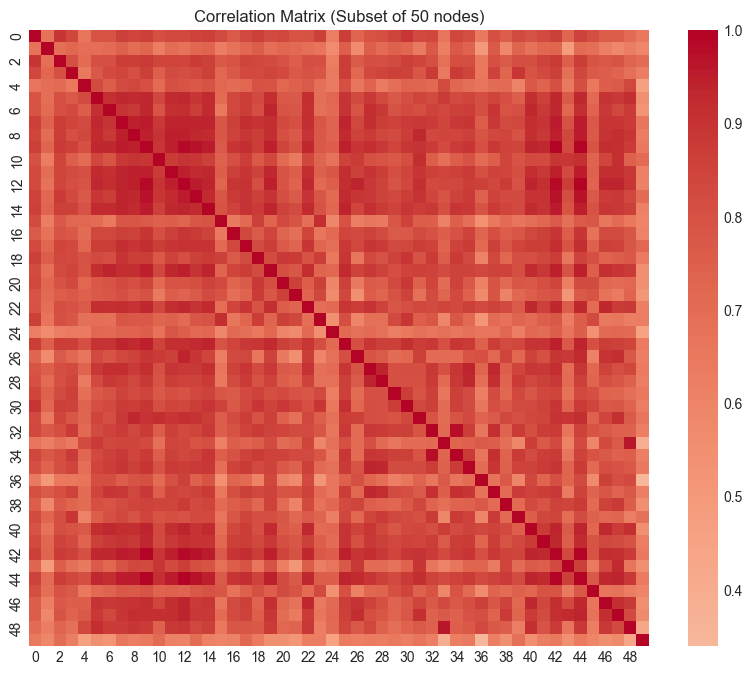

In [6]:
## 4. Covariance & Correlation Study
def study_correlation(data_array, feature_idx=0, nodes_subset=None):
    """
    Study the correlation/covariance structure of a subset of nodes
    """
    if nodes_subset is None:
        # Just take first 50 nodes if not specified, to avoid huge matrices
        nodes_subset = np.arange(min(50, data_array.shape[1]))
        
    subset_data = data_array[:, nodes_subset, feature_idx]
    
    # Correlation Matrix
    corr_matrix = np.corrcoef(subset_data.T)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
    plt.title(f'Correlation Matrix (Subset of {len(nodes_subset)} nodes)')
    plt.show()
    
    return corr_matrix
    
# Let\'s look at correlation of the first 50 nodes
corr_mx = study_correlation(data, feature_idx=FEATURE_IDX)

In [7]:
## 5. Adjacency Matrix Analysis
if adj is not None:
    print('--- Adjacency Matrix Structure ---')
    # Calculate basic graph metrics if adj is present
    try:
        metrics = calculate_graph_metrics(adj)
        for k, v in metrics.items():
            print(f'{k}: {v}')
    except Exception as e:
        print(f'Failed to compute graph metrics: {e}')
else:
    print('No adjacency matrix found for this dataset.')

--- Adjacency Matrix Structure ---
num_nodes: 883
total_edges: 1732
density: 0.0022239171244186613
sparsity: 0.9977786014680212
avg_connection_strength: 1.0
clustering_coefficient: 0.0
algebraic_connectivity: -6.202438990334609e-16
spectral_gap: 0.1147162914276123
num_components: 17
is_connected: False
min_degree: 2
max_degree: 8
mean_degree: 3.9229898074745186
median_degree: 4.0
mode_degree: 4
std_degree: 0.6193951922638915
q1_degree: 4.0
q3_degree: 4.0
reciprocity: 0.5
mean_in_degree: 1.9614949037372593
mean_out_degree: 1.9614949037372593
